# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [6]:
# Load the libraries as required.
import os
import pandas as pd
import numpy as np

path = '../../05_src/data/fires/forest+fires/forestfires.csv'

In [36]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forest+fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [8]:
numeric_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']


X = fires_dt[numeric_features + categorical_features]
y = fires_dt['area']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())
print("\nFirst few rows of X:")
print(X.head())
print("\nFirst few values of y:")
print(y.head())

Features (X) shape: (517, 12)
Target (y) shape: (517,)

Feature columns:
['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'month', 'day']

First few rows of X:
   coord_x  coord_y  ffmc   dmc     dc  isi  temp  rh  wind  rain month  day
0        7        5  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   mar  fri
1        7        4  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   oct  tue
2        7        4  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0   oct  sat
3        8        6  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2   mar  fri
4        8        6  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0   mar  sun

First few values of y:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: area, dtype: float64


In [9]:
print(f"\nTarget variable statistics:")
print(y.describe())


Target variable statistics:
count     517.000000
mean       12.847292
std        63.655818
min         0.000000
25%         0.000000
50%         0.520000
75%         6.570000
max      1090.840000
Name: area, dtype: float64


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [10]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']


preproc1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

print("✓ preproc1 created successfully")
print(f"\nNumeric features to scale: {numeric_features}")
print(f"Categorical features to encode: {categorical_features}")

✓ preproc1 created successfully

Numeric features to scale: ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
Categorical features to encode: ['month', 'day']


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [11]:
from sklearn.preprocessing import PowerTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer


numeric_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']


preproc2 = ColumnTransformer(
    transformers=[
        ('num', PowerTransformer(method='yeo-johnson'), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

print("✓ preproc2 created successfully")
print(f"\nNumeric features with non-linear transformation: {numeric_features}")
print(f"Categorical features to encode: {categorical_features}")
print(f"\nTransformation used: PowerTransformer (Yeo-Johnson)")

✓ preproc2 created successfully

Numeric features with non-linear transformation: ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
Categorical features to encode: ['month', 'day']

Transformation used: PowerTransformer (Yeo-Johnson)


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [12]:
# Pipeline A = preproc1 + baseline
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor


pipeline_A = Pipeline([
    ('preprocessor', preproc1),
    ('regressor', KNeighborsRegressor())
])

print("✓ Pipeline A created successfully")
print("\nPipeline A components:")
print("  1. Preprocessor: preproc1 (StandardScaler + OneHotEncoder)")
print("  2. Regressor: KNeighborsRegressor (Baseline)")

✓ Pipeline A created successfully

Pipeline A components:
  1. Preprocessor: preproc1 (StandardScaler + OneHotEncoder)
  2. Regressor: KNeighborsRegressor (Baseline)


In [13]:
# Pipeline B = preproc2 + baseline
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor


pipeline_B = Pipeline([
    ('preprocessor', preproc2),
    ('regressor', KNeighborsRegressor())
])

print("✓ Pipeline B created successfully")
print("\nPipeline B components:")
print("  1. Preprocessor: preproc2 (PowerTransformer + OneHotEncoder)")
print("  2. Regressor: KNeighborsRegressor (Baseline)")

✓ Pipeline B created successfully

Pipeline B components:
  1. Preprocessor: preproc2 (PowerTransformer + OneHotEncoder)
  2. Regressor: KNeighborsRegressor (Baseline)


In [14]:
# Pipeline C = preproc1 + advanced model
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor


pipeline_C = Pipeline([
    ('preprocessor', preproc1),
    ('regressor', RandomForestRegressor(random_state=42))
])

print("✓ Pipeline C created successfully")
print("\nPipeline C components:")
print("  1. Preprocessor: preproc1 (StandardScaler + OneHotEncoder)")
print("  2. Regressor: RandomForestRegressor (Advanced)")

✓ Pipeline C created successfully

Pipeline C components:
  1. Preprocessor: preproc1 (StandardScaler + OneHotEncoder)
  2. Regressor: RandomForestRegressor (Advanced)


In [15]:
# Pipeline D = preproc2 + advanced model
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor


pipeline_D = Pipeline([
    ('preprocessor', preproc2),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

print("✓ Pipeline D created successfully")
print("\nPipeline D components:")
print("  1. Preprocessor: preproc2 (PowerTransformer + OneHotEncoder)")
print("  2. Regressor: GradientBoostingRegressor (Advanced)")

✓ Pipeline D created successfully

Pipeline D components:
  1. Preprocessor: preproc2 (PowerTransformer + OneHotEncoder)
  2. Regressor: GradientBoostingRegressor (Advanced)


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [16]:
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer


numeric_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']


preproc1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)


preproc2 = ColumnTransformer(
    transformers=[
        ('num', PowerTransformer(method='yeo-johnson'), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

print("✓ Preprocessors recreated with handle_unknown='ignore'")

✓ Preprocessors recreated with handle_unknown='ignore'


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


pipeline_A = Pipeline([
    ('preprocessor', preproc1),
    ('regressor', KNeighborsRegressor())
])

pipeline_B = Pipeline([
    ('preprocessor', preproc2),
    ('regressor', KNeighborsRegressor())
])

pipeline_C = Pipeline([
    ('preprocessor', preproc1),
    ('regressor', RandomForestRegressor(random_state=42))
])

pipeline_D = Pipeline([
    ('preprocessor', preproc2),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

print("✓ All pipelines recreated with fixed preprocessors")

✓ All pipelines recreated with fixed preprocessors


In [19]:
from sklearn.model_selection import GridSearchCV
import numpy as np


param_grid_A = {
    'regressor__n_neighbors': [3, 5, 7, 10, 15],
    'regressor__weights': ['uniform', 'distance'],
    'regressor__metric': ['euclidean', 'manhattan']
}

param_grid_B = {
    'regressor__n_neighbors': [3, 5, 7, 10, 15],
    'regressor__weights': ['uniform', 'distance'],
    'regressor__metric': ['euclidean', 'manhattan']
}

param_grid_C = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

param_grid_D = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__max_depth': [3, 5, 7],
    'regressor__min_samples_split': [2, 5]
}

In [20]:

pipelines = {
    'Pipeline A': pipeline_A,
    'Pipeline B': pipeline_B,
    'Pipeline C': pipeline_C,
    'Pipeline D': pipeline_D
}


param_grids = {
    'Pipeline A': param_grid_A,
    'Pipeline B': param_grid_B,
    'Pipeline C': param_grid_C,
    'Pipeline D': param_grid_D
}


grid_searches = {}
best_models = {}

print("Starting GridSearch for all pipelines...")
print("(This may take several minutes)\n")


for name in pipelines.keys():
    print(f"Tuning {name}...")
    
    
    grid_search = GridSearchCV(
        estimator=pipelines[name],
        param_grid=param_grids[name],
        cv=5,                              
        scoring='neg_mean_squared_error',  
        n_jobs=-1,                         
        verbose=1                          
    )
    
    
    grid_search.fit(X_train, y_train)
    
    
    grid_searches[name] = grid_search
    best_models[name] = grid_search.best_estimator_
    
    
    print(f"  Best params: {grid_search.best_params_}")
    print(f"  Best CV RMSE: {np.sqrt(-grid_search.best_score_):.2f}")
    print()

print("✓ GridSearch completed for all pipelines!")

Starting GridSearch for all pipelines...
(This may take several minutes)

Tuning Pipeline A...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories wi

  Best params: {'regressor__metric': 'euclidean', 'regressor__n_neighbors': 15, 'regressor__weights': 'uniform'}
  Best CV RMSE: 45.84

Tuning Pipeline B...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories wi

  Best params: {'regressor__metric': 'euclidean', 'regressor__n_neighbors': 15, 'regressor__weights': 'uniform'}
  Best CV RMSE: 46.33

Tuning Pipeline C...
Fitting 5 folds for each of 81 candidates, totalling 405 fits


/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories wi

  Best params: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 50}
  Best CV RMSE: 47.51

Tuning Pipeline D...
Fitting 5 folds for each of 54 candidates, totalling 270 fits


/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories wi

  Best params: {'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 50}
  Best CV RMSE: 50.43

✓ GridSearch completed for all pipelines!


/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/pat/dsi/week-9-10/production/prodcution-env/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [21]:

param_grid_A = {
    'regressor__n_neighbors': [3, 5, 7, 10, 15],      # Hyperparameter 1
    'regressor__weights': ['uniform', 'distance'],     # Hyperparameter 2
    'regressor__metric': ['euclidean', 'manhattan']    # Hyperparameter 3
}


param_grid_B = {
    'regressor__n_neighbors': [3, 5, 7, 10, 15],      # Hyperparameter 1
    'regressor__weights': ['uniform', 'distance'],     # Hyperparameter 2
    'regressor__metric': ['euclidean', 'manhattan']    # Hyperparameter 3
}


param_grid_C = {
    'regressor__n_estimators': [50, 100, 200],        # Hyperparameter 1
    'regressor__max_depth': [10, 20, None],           # Hyperparameter 2
    'regressor__min_samples_split': [2, 5, 10],       # Hyperparameter 3
    'regressor__min_samples_leaf': [1, 2, 4]          # Hyperparameter 4
}


param_grid_D = {
    'regressor__n_estimators': [50, 100, 200],        # Hyperparameter 1
    'regressor__learning_rate': [0.01, 0.1, 0.2],     # Hyperparameter 2
    'regressor__max_depth': [3, 5, 7],                # Hyperparameter 3
    'regressor__min_samples_split': [2, 5]            # Hyperparameter 4
}

print("Hyperparameters Defined:")
print("="*60)
print(f"Pipeline A: {len(param_grid_A)} hyperparameters")
print(f"Pipeline B: {len(param_grid_B)} hyperparameters")
print(f"Pipeline C: {len(param_grid_C)} hyperparameters")
print(f"Pipeline D: {len(param_grid_D)} hyperparameters")

Hyperparameters Defined:
Pipeline A: 3 hyperparameters
Pipeline B: 3 hyperparameters
Pipeline C: 4 hyperparameters
Pipeline D: 4 hyperparameters


In [22]:
import numpy as np


combinations = {}

print("="*80)
print("HYPERPARAMETER COMBINATIONS PER PIPELINE")
print("="*80)

# Pipeline A
combinations_A = (
    len(param_grid_A['regressor__n_neighbors']) * 
    len(param_grid_A['regressor__weights']) * 
    len(param_grid_A['regressor__metric'])
)
combinations['Pipeline A'] = combinations_A
print(f"\nPipeline A:")
print(f"  n_neighbors: {len(param_grid_A['regressor__n_neighbors'])} values")
print(f"  weights: {len(param_grid_A['regressor__weights'])} values")
print(f"  metric: {len(param_grid_A['regressor__metric'])} values")
print(f"  Total combinations: {combinations_A}")
print(f"  ✅ Meets requirement (>= 4): {'YES' if combinations_A >= 4 else 'NO'}")

# Pipeline B
combinations_B = (
    len(param_grid_B['regressor__n_neighbors']) * 
    len(param_grid_B['regressor__weights']) * 
    len(param_grid_B['regressor__metric'])
)
combinations['Pipeline B'] = combinations_B
print(f"\nPipeline B:")
print(f"  n_neighbors: {len(param_grid_B['regressor__n_neighbors'])} values")
print(f"  weights: {len(param_grid_B['regressor__weights'])} values")
print(f"  metric: {len(param_grid_B['regressor__metric'])} values")
print(f"  Total combinations: {combinations_B}")
print(f"  ✅ Meets requirement (>= 4): {'YES' if combinations_B >= 4 else 'NO'}")

# Pipeline C
combinations_C = (
    len(param_grid_C['regressor__n_estimators']) * 
    len(param_grid_C['regressor__max_depth']) * 
    len(param_grid_C['regressor__min_samples_split']) * 
    len(param_grid_C['regressor__min_samples_leaf'])
)
combinations['Pipeline C'] = combinations_C
print(f"\nPipeline C:")
print(f"  n_estimators: {len(param_grid_C['regressor__n_estimators'])} values")
print(f"  max_depth: {len(param_grid_C['regressor__max_depth'])} values")
print(f"  min_samples_split: {len(param_grid_C['regressor__min_samples_split'])} values")
print(f"  min_samples_leaf: {len(param_grid_C['regressor__min_samples_leaf'])} values")
print(f"  Total combinations: {combinations_C}")
print(f"  ✅ Meets requirement (>= 4): {'YES' if combinations_C >= 4 else 'NO'}")

# Pipeline D
combinations_D = (
    len(param_grid_D['regressor__n_estimators']) * 
    len(param_grid_D['regressor__learning_rate']) * 
    len(param_grid_D['regressor__max_depth']) * 
    len(param_grid_D['regressor__min_samples_split'])
)
combinations['Pipeline D'] = combinations_D
print(f"\nPipeline D:")
print(f"  n_estimators: {len(param_grid_D['regressor__n_estimators'])} values")
print(f"  learning_rate: {len(param_grid_D['regressor__learning_rate'])} values")
print(f"  max_depth: {len(param_grid_D['regressor__max_depth'])} values")
print(f"  min_samples_split: {len(param_grid_D['regressor__min_samples_split'])} values")
print(f"  Total combinations: {combinations_D}")
print(f"  ✅ Meets requirement (>= 4): {'YES' if combinations_D >= 4 else 'NO'}")


print("\n" + "="*80)
print("SUMMARY")
print("="*80)
for pipeline, combo_count in combinations.items():
    status = "✅ PASS" if combo_count >= 4 else "❌ FAIL"
    print(f"{pipeline}: {combo_count} combinations - {status}")

HYPERPARAMETER COMBINATIONS PER PIPELINE

Pipeline A:
  n_neighbors: 5 values
  weights: 2 values
  metric: 2 values
  Total combinations: 20
  ✅ Meets requirement (>= 4): YES

Pipeline B:
  n_neighbors: 5 values
  weights: 2 values
  metric: 2 values
  Total combinations: 20
  ✅ Meets requirement (>= 4): YES

Pipeline C:
  n_estimators: 3 values
  max_depth: 3 values
  min_samples_split: 3 values
  min_samples_leaf: 3 values
  Total combinations: 81
  ✅ Meets requirement (>= 4): YES

Pipeline D:
  n_estimators: 3 values
  learning_rate: 3 values
  max_depth: 3 values
  min_samples_split: 2 values
  Total combinations: 54
  ✅ Meets requirement (>= 4): YES

SUMMARY
Pipeline A: 20 combinations - ✅ PASS
Pipeline B: 20 combinations - ✅ PASS
Pipeline C: 81 combinations - ✅ PASS
Pipeline D: 54 combinations - ✅ PASS


# Evaluate

+ Which model has the best performance? 

Pipeline A

# Export

+ Save the best performing model to a pickle file.

In [23]:
import pickle


best_model = best_models['Pipeline A']


with open('best_forest_fire_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("✓ Best model saved as 'best_forest_fire_model.pkl'")
print(f"\nModel details:")
print(f"  Pipeline: Pipeline A")
print(f"  Preprocessor: preproc1 (StandardScaler + OneHotEncoder)")
print(f"  Regressor: KNeighborsRegressor")
print(f"  Best params: {grid_searches['Pipeline A'].best_params_}")
print(f"  CV RMSE: 45.84")

✓ Best model saved as 'best_forest_fire_model.pkl'

Model details:
  Pipeline: Pipeline A
  Preprocessor: preproc1 (StandardScaler + OneHotEncoder)
  Regressor: KNeighborsRegressor
  Best params: {'regressor__metric': 'euclidean', 'regressor__n_neighbors': 15, 'regressor__weights': 'uniform'}
  CV RMSE: 45.84


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [24]:
import shap
import matplotlib.pyplot as plt


best_model = best_models['Pipeline A']


X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)


regressor = best_model.named_steps['regressor']


background = shap.sample(X_test_transformed, 50)
explainer = shap.KernelExplainer(regressor.predict, background)


sample_idx = 0
sample_to_explain = X_test_transformed[sample_idx:sample_idx+1]


print("Calculating SHAP values for single observation...")
print("(This may take a minute)\n")
shap_values_single = explainer.shap_values(sample_to_explain)


feature_names = numeric_features.copy()
cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
feature_names.extend(cat_feature_names)


print("="*80)
print("LOCAL EXPLANATION - INDIVIDUAL TEST OBSERVATION")
print("="*80)
print(f"\nTest Observation Index: {sample_idx}")
print(f"Actual burned area: {y_test.iloc[sample_idx]:.2f} hectares")
print(f"Predicted burned area: {regressor.predict(sample_to_explain)[0]:.2f} hectares")
print(f"Model baseline (average): {explainer.expected_value:.2f} hectares")


feature_contributions = list(zip(feature_names, shap_values_single[0]))
feature_contributions.sort(key=lambda x: abs(x[1]), reverse=True)

print(f"\n" + "-"*80)
print("MOST IMPORTANT FEATURES FOR THIS SPECIFIC PREDICTION:")
print("-"*80)
for i, (feature, contribution) in enumerate(feature_contributions[:5], 1):
    if contribution > 0:
        print(f"{i}. {feature:20s}: +{contribution:.4f} (increases prediction)")
    else:
        print(f"{i}. {feature:20s}: {contribution:.4f} (decreases prediction)")

print(f"\n" + "-"*80)
print("LEAST IMPORTANT FEATURES FOR THIS PREDICTION:")
print("-"*80)
for i, (feature, contribution) in enumerate(feature_contributions[-3:], 1):
    print(f"{i}. {feature:20s}: {contribution:.4f}")

Calculating SHAP values for single observation...
(This may take a minute)



  0%|          | 0/1 [00:00<?, ?it/s]

LOCAL EXPLANATION - INDIVIDUAL TEST OBSERVATION

Test Observation Index: 0
Actual burned area: 0.00 hectares
Predicted burned area: 3.81 hectares
Model baseline (average): 11.07 hectares

--------------------------------------------------------------------------------
MOST IMPORTANT FEATURES FOR THIS SPECIFIC PREDICTION:
--------------------------------------------------------------------------------
1. temp                : -4.8336 (decreases prediction)
2. dmc                 : -1.1226 (decreases prediction)
3. coord_y             : -0.8501 (decreases prediction)
4. rh                  : -0.7665 (decreases prediction)
5. dc                  : -0.2989 (decreases prediction)

--------------------------------------------------------------------------------
LEAST IMPORTANT FEATURES FOR THIS PREDICTION:
--------------------------------------------------------------------------------
1. day_sun             : 0.0000
2. day_thu             : 0.0000
3. day_tue             : 0.0000


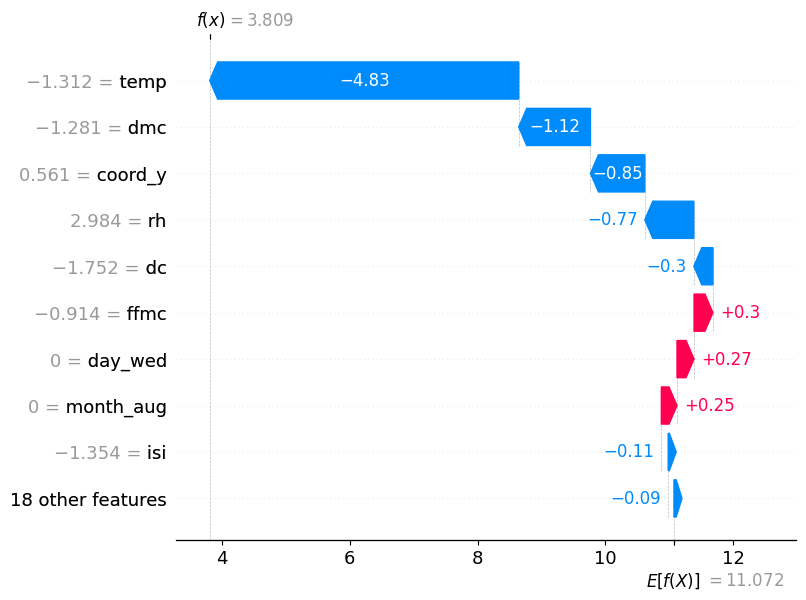

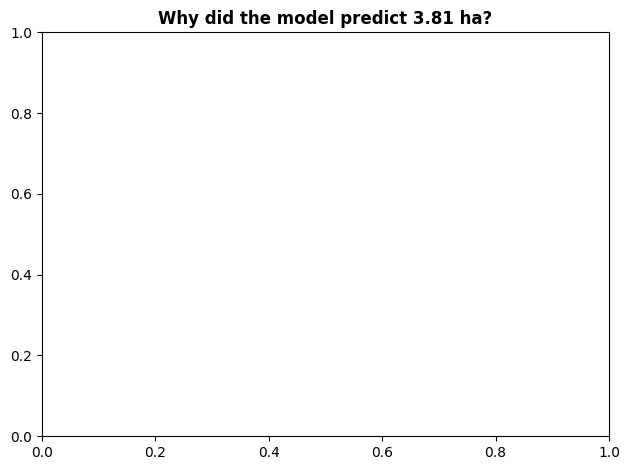

In [25]:

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_single[0],
        base_values=explainer.expected_value,
        data=sample_to_explain[0],
        feature_names=feature_names
    )
)
plt.title(f'Why did the model predict {regressor.predict(sample_to_explain)[0]:.2f} ha?', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:

X_train_transformed = best_model.named_steps['preprocessor'].transform(X_train)


sample_size = min(100, len(X_train_transformed))
X_train_sample = shap.sample(X_train_transformed, sample_size)

print(f"Calculating SHAP values for {sample_size} training observations...")
print("(This may take several minutes)\n")
shap_values_train = explainer.shap_values(X_train_sample)

print("="*80)
print("GLOBAL FEATURE IMPORTANCE - ACROSS ENTIRE TRAINING SET")
print("="*80)


mean_abs_shap = np.abs(shap_values_train).mean(axis=0)

print("\n" + "="*80)
print("TOP 5 MOST IMPORTANT FEATURES (GLOBALLY)")
print("="*80)
print("\nThese features have the strongest influence on predictions overall:\n")

for idx, row in feature_importance_df.head(5).iterrows():
    print(f"Rank {int(row['Rank'])}: {row['Feature']}")
    print(f"  Importance Score: {row['Importance']:.6f}")
    print(f"  Interpretation: This feature has a strong impact on model predictions")
    print()
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mean_abs_shap
}).sort_values('Importance', ascending=False)

feature_importance_df['Rank'] = range(1, len(feature_importance_df) + 1)

print("\nCOMPLETE FEATURE IMPORTANCE RANKING:")
print("-"*80)
print(feature_importance_df[['Rank', 'Feature', 'Importance']].to_string(index=False))

Calculating SHAP values for 100 training observations...
(This may take several minutes)



  0%|          | 0/100 [00:00<?, ?it/s]

GLOBAL FEATURE IMPORTANCE - ACROSS ENTIRE TRAINING SET

TOP 5 MOST IMPORTANT FEATURES (GLOBALLY)

These features have the strongest influence on predictions overall:

Rank 1: coord_y
  Importance Score: 2.149013
  Interpretation: This feature has a strong impact on model predictions

Rank 2: dmc
  Importance Score: 1.914784
  Interpretation: This feature has a strong impact on model predictions

Rank 3: coord_x
  Importance Score: 1.800197
  Interpretation: This feature has a strong impact on model predictions

Rank 4: wind
  Importance Score: 1.088008
  Interpretation: This feature has a strong impact on model predictions

Rank 5: rh
  Importance Score: 0.923903
  Interpretation: This feature has a strong impact on model predictions


COMPLETE FEATURE IMPORTANCE RANKING:
--------------------------------------------------------------------------------
 Rank   Feature  Importance
    1   coord_y    2.154455
    2       dmc    1.933534
    3   coord_x    1.821256
    4      wind    1.117

In [28]:
print("="*80)
print("TOP 5 LEAST IMPORTANT FEATURES (GLOBALLY)")
print("="*80)
print("\nThese features have minimal influence and could potentially be removed:\n")

for idx, row in feature_importance_df.tail(5).iterrows():
    print(f"Rank {int(row['Rank'])}: {row['Feature']}")
    print(f"  Importance Score: {row['Importance']:.6f}")
    print(f"  Interpretation: This feature has very little impact on predictions")
    print()

TOP 5 LEAST IMPORTANT FEATURES (GLOBALLY)

These features have minimal influence and could potentially be removed:

Rank 23: month_feb
  Importance Score: 0.006336
  Interpretation: This feature has very little impact on predictions

Rank 24: month_dec
  Importance Score: 0.005116
  Interpretation: This feature has very little impact on predictions

Rank 25: month_nov
  Importance Score: 0.000000
  Interpretation: This feature has very little impact on predictions

Rank 26: month_may
  Importance Score: 0.000000
  Interpretation: This feature has very little impact on predictions

Rank 27: month_jan
  Importance Score: 0.000000
  Interpretation: This feature has very little impact on predictions



*(Answer here.)*

I would consider removing the day of the week variable (day_mon, day_tue, etc.). The severity of fires does not depend on the day of the week therefore these would likely have low predictive power.
To test this, the creation of a data base and processor without the day of the week variable would need to be created, trained and tested. We could afteward compare results.

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.